# Pucktrick data quality


Thesis project

In [ ]:
LOCAL_RUN = True  

PATH_IMG = "images"

if LOCAL_RUN:
    PATH = "DATASETS"
else:
    PATH = "file:///home/PuckTrickadmin/DATASETS"

In [ ]:
MISSING_DATA_ALREADY_REMOVED = True
null_count_features = 0

## 0. Notebook setup

In [ ]:
!pip install -r requirements.txt
%pip install setuptools yellowbrick


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# import delle librerie necessarie
import numpy as np
import pandas as pd  # used for toPandas() visualization conversions
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Noto Sans Nabataean, Nimbus Sans, Nimbus Roman'
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, count, when, isnan
# split dataset in train and test set
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
# RFECV - no direct Spark equivalent; keeping sklearn for cross-validation strategies
from sklearn.model_selection import StratifiedKFold
import os
import glob
from sklearn.metrics import matthews_corrcoef, make_scorer
import seaborn as sns
import os
import subprocess
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

In [ ]:
if(LOCAL_RUN):
    # Check Java installation
    java_home = os.environ.get('JAVA_HOME', '')
    if not java_home:
        # Try to find Java automatically
        try:
            java_path = subprocess.check_output(['which', 'java'], text=True).strip()
            java_home = os.path.dirname(os.path.dirname(os.path.realpath(java_path)))
            os.environ['JAVA_HOME'] = java_home
            print(f"Found Java at: {java_home}")
        except subprocess.CalledProcessError:
            print("Java not found! Please install Java 8 or 11.")
            print("Run: sudo apt install default-jdk")

    os.environ['PYSPARK_PYTHON'] = 'python3'
    os.environ['PYSPARK_DRIVER_PYTHON'] = 'python3'

    # Initialize Spark session
    spark = SparkSession.builder \
        .appName("PucktrickDataQuality") \
        .master("local[*]") \
        .config("spark.driver.memory", "4g") \
        .config("spark.driver.host", "localhost") \
        .config("spark.ui.showConsoleProgress", "false") \
        .getOrCreate()

    print(f"Spark version: {spark.version}")

Found Java at: /usr/lib/jvm/java-11-openjdk


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/01 16:55:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.0


In [ ]:
if not LOCAL_RUN:
    MASTER_URL   = "spark://10.0.1.8:7077"
    DRIVER_HOST  = "10.0.1.8"

    spark = SparkSession.builder \
        .appName("Cavas_Analysis") \
        .master(MASTER_URL) \
        .config("spark.submit.deployMode",      "client") \
        .config("spark.executor.instances",     "4") \
        .config("spark.executor.cores",         "4") \
        .config("spark.executor.memory",        "13g") \
        .config("spark.driver.memory",          "8g") \
        .config("spark.driver.host",            DRIVER_HOST) \
        .config("spark.driver.bindAddress",     DRIVER_HOST) \
        .config("spark.sql.shuffle.partitions", "32") \
        .getOrCreate()

    spark.sparkContext.setLogLevel("WARN")
    print("SparkSession creata — versione:", spark.version)

## 1. Dataset Exploration

In [ ]:
# Lettura del dataset con Spark
if not os.path.exists(f'{PATH}/all.parquet'):
    dataset = spark.read.csv(f'{PATH}/all.csv', header=True, inferSchema=True)
    # Salva il dataset in formato Parquet per un caricamento più veloce in futuro
    dataset.write.parquet(f'{PATH}/all.parquet', mode='overwrite')
else:
    dataset = spark.read.parquet(f'{PATH}/all.parquet')

In [ ]:
# Mi salvo target e features in variabili diverse
uni_target = dataset.select('Label')
uni_target_generic = dataset.select('Label_generic')
uni_feature = dataset.drop('Label', 'Label_generic')

In [ ]:
uni_feature.show(5)

26/03/01 16:55:53 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------+--------+-------------------+-------------+------------+------------+---------------+---------------+---------------+---------------+----------------+---------------+---------------+---------------+----------------+---------------+--------------+------------+----------------+----------------+------------+------------+-----------+------------+----------------+-----------+-----------+-----------+------------+----------------+-----------+-----------+-------------+-------------+-------------+-------------+--------------+--------------+------------+------------+-----------+-----------+--------------+--------------+----------------+------------+------------+------------+------------+------------+------------+--------------+------------+-------------+--------------+----------------+----------------+--------------+--------------+----------------+--------------+--------------+----------------+----------------+----------------+----------------+----------------+-----------------+-------

### 1.0. Dataset unification

Dataset was splitted into different CSVs. I had to unificate it into one sinfular file before splitting it into train and test.

In [ ]:
skip_unification_dataset = True

In [ ]:
if not skip_unification_dataset:
    # Leggi tutti i file CSV nella cartella "{PATH}"
    csv_files = [f for f in glob.glob(os.path.join('{PATH}', '*.csv')) if os.path.basename(f) != 'all.csv' and os.path.basename(f) != 'scrap.csv']

    output_path = '{PATH}/all.csv'
    scrap_path = '{PATH}/scrap.csv'

    # Rimuovi i file di output se esistono già
    for path in [output_path, scrap_path]:
        if os.path.exists(path):
            os.remove(path)

    # Le colonne di riferimento vengono prese dal primo file e non vengono mai cancellate
    reference_columns = None

    for i, f in enumerate(csv_files):
        df_chunk = pd.read_csv(f)

        if reference_columns is None:
            # Salva le colonne del primo file come riferimento
            reference_columns = df_chunk.columns.tolist()
            df_chunk.to_csv(output_path, mode='a', index=False, header=True)
        else:
            # Colonne in comune con il riferimento
            common_cols = [c for c in reference_columns if c in df_chunk.columns]
            # Colonne extra non presenti nel riferimento
            extra_cols = [c for c in df_chunk.columns if c not in reference_columns]

            # Scrivi le colonne comuni in all.csv
            df_common = df_chunk[common_cols]
            # Aggiungi colonne mancanti rispetto al riferimento come NaN
            for col in reference_columns:
                if col not in df_common.columns:
                    df_common[col] = np.nan
            df_common = df_common[reference_columns]
            df_common.to_csv(output_path, mode='a', index=False, header=False)
            del df_common

            # Scrivi le colonne extra in scrap.csv
            if extra_cols:
                df_scrap = df_chunk[extra_cols].copy()
                df_scrap.insert(0, 'source_file', os.path.basename(f))
                df_scrap.to_csv(scrap_path, mode='a', index=False, header=(not os.path.exists(scrap_path) or i == 1))
                del df_scrap

        # Pulisci la RAM (ma non reference_columns)
        del df_chunk

        print(f'[{i+1}/{len(csv_files)}] Processato: {f}')

    print(f'\nUniti {len(csv_files)} file CSV in "{output_path}"')
    print(f'Colonne di riferimento ({len(reference_columns)}): {reference_columns}')

notably one of the 10 days had 4 more features that were dropped into final dataset. Yet, to avoid losing the information the scrapped data was stored into 'scrap.csv' as those columns mmight have great relevance for our experiment. 
Later we'll see if we want to experiment with them or not.

### 1.1. Dataset dimensionality

In [ ]:
# Mi salvo in una variabile il numero di features per dopo
n_features0 = len(dataset.columns) - 2 
# Sottraggo 2 perché tolgo la colonna "Label" e "Label_generic" che non sono feature ma target

# Stampo il numero di records e di features
print(f'There are {dataset.count()} instances \nand a total of {n_features0} features!')

There are 16173281 instances 
and a total of 79 features!


### 1.2. Unbalanced dataset

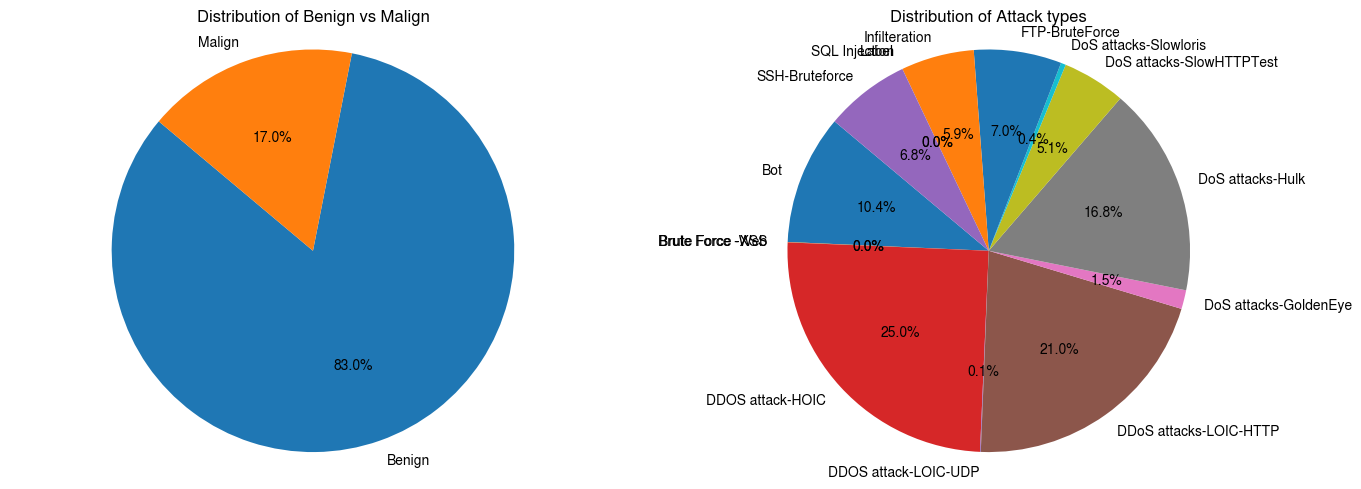

In [ ]:
# Conta le occorrenze per ogni valore di Label e Label_generic
label_counts_pd = uni_target.groupBy('Label').count().orderBy('Label').toPandas()
label_generic_counts_pd = uni_target_generic.groupBy('Label_generic').count().orderBy('Label_generic').toPandas()

# Filtra label_counts per escludere Benign
label_counts_no_benign = label_counts_pd[label_counts_pd['Label'] != 'Benign']

# Visualizzali in due piechart affiancati
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.pie(label_generic_counts_pd['count'], labels=['Benign', 'Malign'], autopct='%1.1f%%', startangle=140)
ax1.set_title('Distribution of Benign vs Malign')
ax1.axis('equal')

ax2.pie(label_counts_no_benign['count'], labels=label_counts_no_benign['Label'].astype(str), autopct='%1.1f%%', startangle=140)
ax2.set_title('Distribution of Attack types')
ax2.axis('equal')

plt.tight_layout()
plt.savefig(f'{PATH_IMG}/label_distribution_piecharts.png')
plt.show()

As we can see, the dataset is clearly very unbalanced. To try even the playing field for both positive (malign package) and negative (benign) can added a second target column that classifies all kinds of attacks as simply 'Malign'; having:
- first target: benign - malign (0-1)
- second target: bening - all other error subclasses 

This way, we can analyze a much more interesting case study! We will use a model capable of predicting two labels and then we'll be able to:

- First, we will observe how the prediction performance of the first label decreases depending on how much we corrupt the various features.
- Second, when the first prediction remains correct (despite the introduction of errors in the dataset), we can examine how the modification has led the model to hallucinate one type of attack rather than another.


### 1.3. Temporal distribution of label

### 1.4. Missing data?

In [ ]:
if not MISSING_DATA_ALREADY_REMOVED:
    # Conta le features con valori mancanti (null)
    null_counts = uni_feature.select([
        count(when(col(c).isNull(), c)).alias(c)
        for c in uni_feature.columns
    ]).toPandas()

    null_count_features = int((null_counts > 0).sum(axis=1).iloc[0])

print(f"in totale ci sono {null_count_features}/{n_features0} features con valori mancanti")

in totale ci sono 0/79 features con valori mancanti


it seemed like only one fefature has missing values, let's investrigate further:

In [ ]:
def conteggio_valori_nulli_per_colonna(df):
    # Conta i null per ogni colonna
    null_counts = df.select([
        count(when(col(c).isNull(), c)).alias(c)
        for c in df.columns
    ]).collect()[0]

    # Filtra solo le colonne con almeno un valore nullo
    colonne_con_null = [(c, null_counts[c]) for c in df.columns if null_counts[c] > 0]
    # Ordina per numero di null decrescente
    colonne_con_null_sorted = sorted(colonne_con_null, key=lambda x: x[1], reverse=True)
    print(f"Ci sono {len(colonne_con_null_sorted)} colonne con valori nulli su {len(df.columns)} totali.")

    for colonna, num_valori_nulli in colonne_con_null_sorted:
        print(f"Colonna '{colonna}': {num_valori_nulli} valori nulli")
        print(f"Percentuale di valori nulli: {num_valori_nulli / df.count() * 100:.2f}%")
        print()
        if num_valori_nulli > 0:
            print("Record con valori nulli:")
            records_con_null = df.filter(col(colonna).isNull())
            records_con_null.show(truncate=False)

By running above function it was shown that only 0.37% of all rows had some missing data inside a single feature. To avoid starting with missing data we decided to drop the rows containing missing data (most of them were also negative cases so it has very few impact on final outcome)

In [ ]:
if null_count_features > 0:
    conteggio_valori_nulli_per_colonna(dataset)

since those rows represent not even 1% of total dataset it's decided to delete them

In [ ]:
if null_count_features > 0:
    # Drop delle righe con valori nulli
    dataset = dataset.na.drop()
    conteggio_valori_nulli_per_colonna(dataset)

### 1.5. Categorical features

In [ ]:
#save dataset to parquet
if not os.path.exists(f'{PATH}/all.parquet'):
    dataset.write.parquet(f'{PATH}/all.parquet', mode='overwrite')

### 1.6. Feature distribution

Understanding the distribution of each feature is crucial to your design: when injecting noise with pucktrick, you need to know what "normality" is to quantify the deviation. Features with highly skewed distributions or natural outliers will react differently to noise.

In [ ]:
# ── Calcolo statistiche descrittive per tutte le feature numeriche ──
# Escludo colonne non numeriche e target
exclude = ['Timestamp', 'Label', 'label_generic', 'Protocol']
# All feature columns are stored as string; select those that should be numeric and cast them
num_cols = [c for c in dataset.columns if c not in exclude]

# Cast selected columns to double so that aggregate functions work
from pyspark.sql.functions import col as _col
dataset = dataset.select(
    *[_col(c).cast('double').alias(c) if c in num_cols else _col(c) for c in dataset.columns]
)

stats_path = f'{PATH}/feature_distribution_stats.csv'

if not os.path.exists(stats_path):
    # Calcolo mean, stddev, min, max, skewness, kurtosis via Spark
    agg_exprs = []
    for c in num_cols:
        agg_exprs.extend([
            F.mean(col(c)).alias(f'{c}__mean'),
            F.stddev(col(c)).alias(f'{c}__std'),
            F.min(col(c)).alias(f'{c}__min'),
            F.max(col(c)).alias(f'{c}__max'),
            F.skewness(col(c)).alias(f'{c}__skew'),
            F.kurtosis(col(c)).alias(f'{c}__kurt'),
        ])

    raw = dataset.agg(*agg_exprs).collect()[0]

    rows = []
    for c in num_cols:
        rows.append({
            'feature': c,
            'mean':     raw[f'{c}__mean'],
            'std':      raw[f'{c}__std'],
            'min':      raw[f'{c}__min'],
            'max':      raw[f'{c}__max'],
            'skewness': raw[f'{c}__skew'],
            'kurtosis': raw[f'{c}__kurt'],
        })

    stats_df = pd.DataFrame(rows)
    stats_df.to_csv(stats_path, index=False)
    print(f"Stats computed and saved to {stats_path}")
else:
    stats_df = pd.read_csv(stats_path)
    print(f"Stats loaded from cache ({stats_path})")

# ── Tabella riassuntiva ──
print(f"\nDescriptive statistics for {len(stats_df)} numeric features:\n")
display(stats_df.round(4))

# ── Evidenzio feature molto skewed (|skewness| > 2) ──
highly_skewed = stats_df[stats_df['skewness'].abs() > 2].sort_values('skewness', key=abs, ascending=False)
print(f"\n⚠ Highly skewed features (|skewness| > 2): {len(highly_skewed)}/{len(stats_df)}")
if len(highly_skewed) > 0:
    display(highly_skewed[['feature', 'skewness', 'kurtosis', 'min', 'max']].reset_index(drop=True))

Stats loaded from cache (DATASETS/feature_distribution_stats.csv)

Descriptive statistics for 77 numeric features:



,feature,mean,std,min,max,skewness,kurtosis
0,Dst Port,9.008606e+03,1.878007e+04,0.000000e+00,6.553500e+04,1.8951,1.764800e+00
1,Flow Duration,1.185742e+07,4.949231e+08,-9.190110e+11,1.200000e+08,-1432.1848,2.164161e+06
2,Tot Fwd Pkts,2.361270e+01,1.523942e+03,1.000000e+00,3.096290e+05,88.3933,8.240874e+03
3,Tot Bwd Pkts,6.336000e+00,1.643277e+02,0.000000e+00,1.231180e+05,170.4904,6.164076e+04
4,TotLen Fwd Pkts,9.766303e+02,6.228371e+04,0.000000e+00,1.443918e+08,835.1456,1.802071e+06
...,...,...,...,...,...,...,...
72,Active Min,1.158920e+05,2.118033e+06,0.000000e+00,1.140000e+08,34.2733,1.274584e+03
73,Idle Mean,5.035484e+06,2.638033e+08,0.000000e+00,3.955714e+11,1259.5487,1.627608e+06
74,Idle Std,2.877076e+05,1.695008e+08,0.000000e+00,2.622479e+11,1305.5366,1.759916e+06
75,Idle Max,5.448188e+06,6.265239e+08,0.000000e+00,9.797810e+11,1329.1651,1.831882e+06



⚠ Highly skewed features (|skewness| > 2): 58/77


,feature,skewness,kurtosis,min,max
0,Flow IAT Mean,-3371.950768,1.202370e+07,-8.282200e+11,1.200000e+08
1,Fwd IAT Mean,-3371.418920,1.202117e+07,-8.282200e+11,1.200000e+08
2,Idle Min,3333.047054,1.242008e+07,0.000000e+00,2.399340e+11
3,Pkt Len Var,1860.550751,4.281155e+06,0.000000e+00,5.190000e+08
4,Fwd IAT Tot,-1432.228205,2.164249e+06,-9.190110e+11,1.200000e+08
5,Flow Duration,-1432.184769,2.164161e+06,-9.190110e+11,1.200000e+08
6,Idle Max,1329.165075,1.831882e+06,0.000000e+00,9.797810e+11
7,Idle Std,1305.536620,1.759916e+06,0.000000e+00,2.622479e+11
8,Idle Mean,1259.548663,1.627608e+06,0.000000e+00,3.955714e+11
9,Flow IAT Std,1206.247169,1.483172e+06,0.000000e+00,4.743545e+11


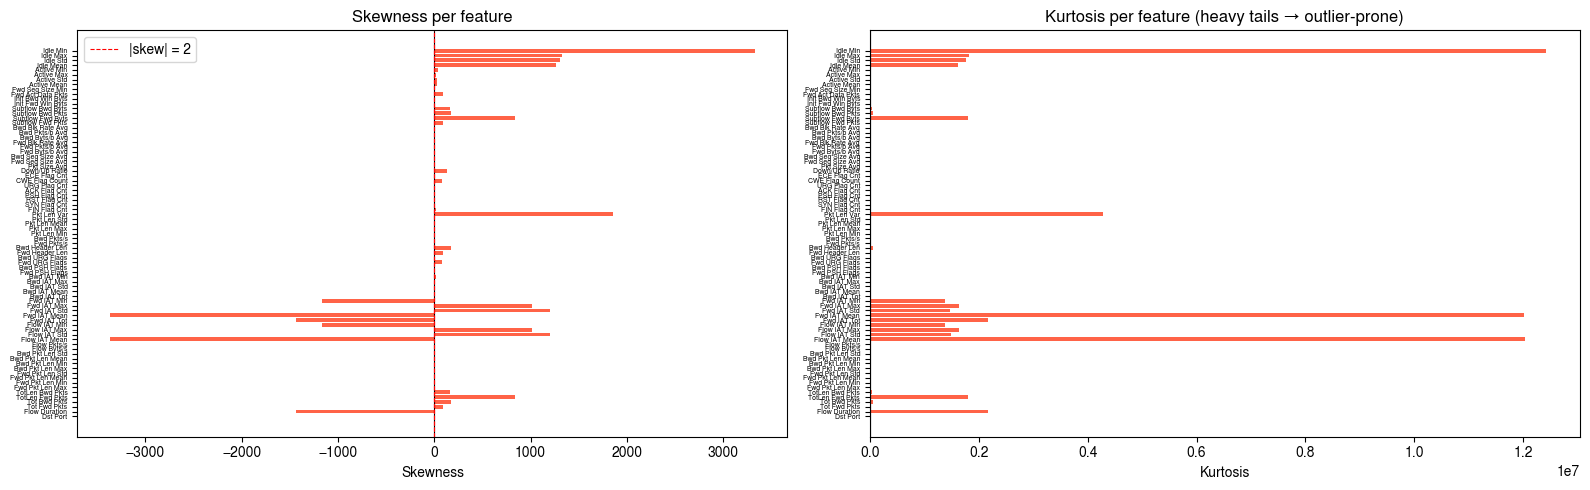

In [ ]:
# ── Visualizzazione: distribuzione di skewness e kurtosis ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(stats_df['feature'], stats_df['skewness'], color=np.where(stats_df['skewness'].abs() > 2, 'tomato', 'steelblue'))
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].axvline(x=2, color='red', linewidth=0.8, linestyle='--', label='|skew| = 2')
axes[0].axvline(x=-2, color='red', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Skewness')
axes[0].set_title('Skewness per feature')
axes[0].tick_params(axis='y', labelsize=5)
axes[0].legend()

axes[1].barh(stats_df['feature'], stats_df['kurtosis'], color=np.where(stats_df['kurtosis'].abs() > 7, 'tomato', 'steelblue'))
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_xlabel('Kurtosis')
axes[1].set_title('Kurtosis per feature (heavy tails → outlier-prone)')
axes[1].tick_params(axis='y', labelsize=5)

plt.tight_layout()
plt.savefig(f'{PATH_IMG}/feature-skew-kurtosis.png', dpi=150)
plt.show()

Skewness (Asimmetria): La skewness misura quanto una distribuzione è asimmetrica rispetto alla media.
- Skewness = 0 → distribuzione simmetrica (es. normale ideale)
- Skewness > 0 → coda più lunga a destra (asimmetria positiva)
- Skewness < 0 → coda più lunga a sinistra (asimmetria negativa)

Kurtosis: indice di quatno sono frequenti outliers:
- Kurtosis ≈ 3 → simile alla distribuzione normale (mesocurtica)
- Kurtosis > 3 → code pesanti, più outlier (leptocurtica)
- Kurtosis < 3 → code leggere, meno outlier (platicurtica)

## 2. Feature relevance study

### 2.1. Bivariate correlation analysis - checking for redundant features

If two features are not independent of each other, they have a high absolute correlation and the information they provide for our LM is essentially the same.

Correlated features generally do not improve models, so one can be eliminated as it is redundant. With the following code we can select highly correlated features (95% correlated with another feature):

Numeric columns used for correlation: 78


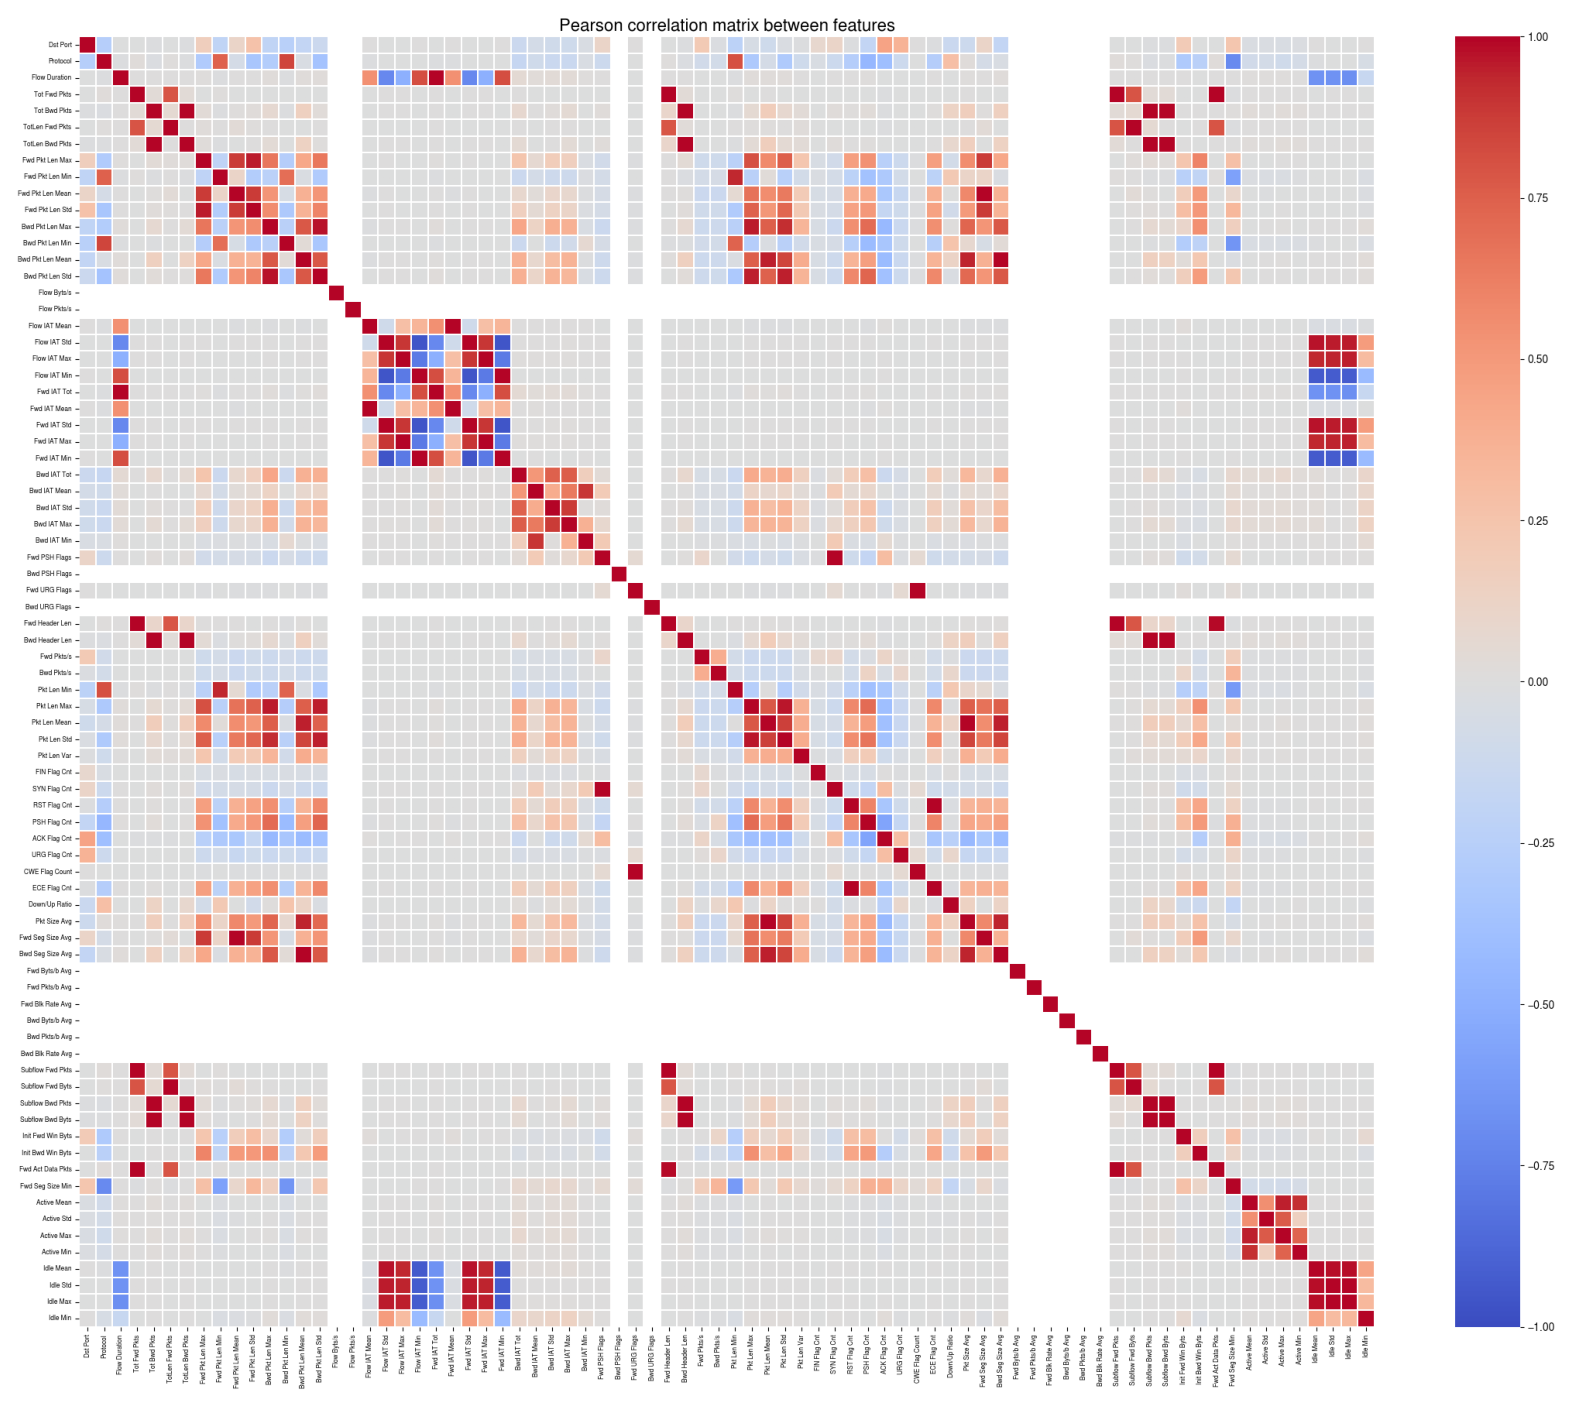

In [ ]:
# Tutte le colonne di uni_feature sono stringhe: castiamo a double quelle che non sono Label/target
# Escludo colonne non numeriche come "Timestamp"
exclude_cols = ['Timestamp']
cast_cols = [c for c in uni_feature.columns if c not in exclude_cols]

uni_feature_numeric = uni_feature
for c in cast_cols:
    uni_feature_numeric = uni_feature_numeric.withColumn(c, col(c).cast('double'))

# Prendo solo le colonne numeriche (ora dovrebbero essere tutte double)
numeric_cols = [
    c for c, dtype in uni_feature_numeric.dtypes
    if dtype in ('int', 'bigint', 'float', 'double')
]
print(f"Numeric columns used for correlation: {len(numeric_cols)}")

# Assemblo tutte le feature numeriche in un unico vettore
assembler = VectorAssembler(inputCols=numeric_cols, outputCol="features", handleInvalid="skip")
df_vector = assembler.transform(uni_feature_numeric.na.drop(subset=numeric_cols)).select("features")

if not os.path.exists(f'{PATH_IMG}/feature-correlation-heatmap.png'):
    # Calcolo la matrice di correlazione di Pearson tramite Spark
    corr_matrix = Correlation.corr(df_vector, "features", method="pearson").head()[0]
    corr_np = corr_matrix.toArray()
    
    # Converto in DataFrame pandas per visualizzazione
    corr_pd = pd.DataFrame(corr_np, index=numeric_cols, columns=numeric_cols)

    # --- Heatmap completa ---
    plt.figure(figsize=(22, 18))
    sns.heatmap(
        corr_pd,
        cmap='coolwarm',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.1,
        xticklabels=True,
        yticklabels=True,
    )
    plt.title('Pearson correlation matrix between features', fontsize=16)
    plt.xticks(fontsize=6, rotation=90)
    plt.yticks(fontsize=6)
    plt.tight_layout()
    plt.savefig(f'{PATH_IMG}/feature-correlation-heatmap.png')
    plt.show()
else:
    #show existing heatmap
    img = plt.imread(f'{PATH_IMG}/feature-correlation-heatmap.png')
    plt.figure(figsize=(22, 18))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

#### 2.1.1. Feature with no variance at all:

In [ ]:
# 1. Feature con varianza zero (costanti)
zero_var_features = []

if not os.path.exists(f'{PATH}/features_to_drop_zero_variance.csv'):
    for c in numeric_cols:
        stats = uni_feature_numeric.select(F.stddev(col(c)).alias('std')).collect()[0]
        if stats['std'] is None or stats['std'] == 0.0:
            zero_var_features.append(c)
    
    #save features to drop to csv
    with open(f'{PATH}/features_to_drop_zero_variance.csv', 'w') as f:
        for feature in sorted(zero_var_features):
            f.write(f"{feature}\n")
else:
    with open(f'{PATH}/features_to_drop_zero_variance.csv', 'r') as f:
        zero_var_features = [line.strip() for line in f if line.strip()]

print(f"Feature with zero variance (Constants): {len(zero_var_features)}")
for f in zero_var_features:
    sample_val = uni_feature_numeric.select(col(f)).filter(col(f).isNotNull()).first()
    print(f"  - {f}  (constant value: {sample_val[0] if sample_val else 'NULL'})")

Feature with zero variance (Constants): 8
  - Bwd Blk Rate Avg  (constant value: 0.0)
  - Bwd Byts/b Avg  (constant value: 0.0)
  - Bwd PSH Flags  (constant value: 0.0)
  - Bwd Pkts/b Avg  (constant value: 0.0)
  - Bwd URG Flags  (constant value: 0.0)
  - Fwd Blk Rate Avg  (constant value: 0.0)
  - Fwd Byts/b Avg  (constant value: 0.0)
  - Fwd Pkts/b Avg  (constant value: 0.0)


#### 2.1.2. Feature with high correlation:

In [ ]:
# --- Identifico coppie altamente correlate (|r| >= 0.95) ---
threshold = 0.95
high_corr_pairs = []

if not os.path.exists(f'{PATH}/high_correlation_pairs.csv'):
    for i in range(len(numeric_cols)):
        for j in range(i + 1, len(numeric_cols)):
            r = corr_np[i][j]
            if abs(r) >= threshold:
                high_corr_pairs.append((numeric_cols[i], numeric_cols[j], round(r, 4)))

    high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Feature_1', 'Feature_2', 'Correlation'])
    high_corr_df = high_corr_df.sort_values('Correlation', key=abs, ascending=False).reset_index(drop=True)
    #save to csv
    high_corr_df.to_csv(f'{PATH}/high_correlation_pairs.csv', index=False)
else:
    high_corr_df = pd.read_csv(f'{PATH}/high_correlation_pairs.csv')

print(f"\nPairs of features with |correlation| >= {threshold}: {len(high_corr_df)}")
display(high_corr_df)


Pairs of features with |correlation| >= 0.95: 46


,Feature_1,Feature_2,Correlation
0,Flow Duration,Fwd IAT Tot,1.0000
1,TotLen Bwd Pkts,Subflow Bwd Byts,1.0000
2,Flow IAT Max,Fwd IAT Max,1.0000
3,Fwd URG Flags,CWE Flag Count,1.0000
4,Flow IAT Std,Fwd IAT Std,1.0000
5,Flow IAT Mean,Fwd IAT Mean,1.0000
6,Bwd Pkt Len Mean,Bwd Seg Size Avg,1.0000
7,RST Flag Cnt,ECE Flag Cnt,1.0000
8,Flow IAT Min,Fwd IAT Min,1.0000
9,Fwd Pkt Len Mean,Fwd Seg Size Avg,1.0000


In [ ]:
# List of candidate features for removal (one for each redundant pair)
features_to_drop = set()

if not os.path.exists(f'{PATH}/features_to_drop_high_correlation.csv'):
    for _, row in high_corr_df.iterrows():
        # Remove the second feature of the pair (arbitrary choice)
        features_to_drop.add(row['Feature_2'])
        
    #save features to drop to csv
    with open(f'{PATH}/features_to_drop_high_correlation.csv', 'w') as f:
        for feature in sorted(features_to_drop):
            f.write(f"{feature}\n")
else:
    features_to_drop_df = pd.read_csv(f'{PATH}/features_to_drop_high_correlation.csv')
    features_to_drop = set(features_to_drop_df['Feature'].tolist())  

print(f"\nCandidate features for removal ({len(features_to_drop)}):")
for f in sorted(features_to_drop):
    print(f"  - {f}")


Candidate features for removal (27):
  - Bwd Header Len
  - Bwd Pkt Len Std
  - Bwd Seg Size Avg
  - CWE Flag Count
  - ECE Flag Cnt
  - Flow IAT Min
  - Fwd Act Data Pkts
  - Fwd Header Len
  - Fwd IAT Max
  - Fwd IAT Mean
  - Fwd IAT Min
  - Fwd IAT Std
  - Fwd IAT Tot
  - Fwd Pkt Len Std
  - Fwd Seg Size Avg
  - Idle Max
  - Idle Mean
  - Idle Std
  - Pkt Len Max
  - Pkt Len Std
  - Pkt Size Avg
  - SYN Flag Cnt
  - Subflow Bwd Byts
  - Subflow Bwd Pkts
  - Subflow Fwd Byts
  - Subflow Fwd Pkts
  - TotLen Bwd Pkts


### 3. Saving the dataset as parquet

In [ ]:
#save dataset to parquet
if not os.path.exists(f'{PATH}/all.parquet'):
    dataset.write.parquet(f'{PATH}/all.parquet', mode='overwrite')